In [1]:
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import sys
sys.path.append('../')

Reference_df = pd.read_csv('../../data/processed/Ref_df.csv')
Test_df = pd.read_csv('../../data/processed/Test_df.csv')

## Form Final_df
selected_cols = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d', 'seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
Final_df = pd.merge(Reference_df, Test_df, how='cross')
Final_df = Final_df[selected_cols]
Final_df['label'] = 0
# Final_df.to_csv('Final_df.csv', index=False)

## Replace / with _
Final_df['seq_id_a'] = Final_df['seq_id_a'].str.replace('/','_')
Final_df['seq_id_b'] = Final_df['seq_id_b'].str.replace('/','_')
Final_df['seq_id_c'] = Final_df['seq_id_c'].str.replace('/','_')
Final_df['seq_id_d'] = Final_df['seq_id_d'].str.replace('/','_')

In [2]:
from utilities import convert_Pass2tensor, load_embedding, generate_matrix

class LucaDataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

In [3]:
from torch.utils.data import DataLoader

Inference_dataset = LucaDataset(Final_df)
Inferecne_dataloader = DataLoader(Inference_dataset, batch_size=10, shuffle=False)

In [76]:
# load embedding
IDs, embeddings = load_embedding("/mnt/chenyihao/workspace/Ma_test/embedding")
emb_dict = dict(zip(IDs, embeddings))

Loading tensor: 100%|██████████| 27/27 [00:00<00:00, 32.29file/s]


In [77]:
import torch
sys.path.append('/mnt/chenyihao/workspace/LucaVirusTasks_source')
sys.path.append('/mnt/chenyihao/workspace/LucaVirusTasks_source/src/lucaquadruple/models')
import model_001

model = torch.load('/mnt/chenyihao/workspace/trained_models/001.pth')
device = torch.device('cuda:0')
prediction_ls = []
reference_ls = []
logits_ls = []
model.eval()
for batch in Inferecne_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/chenyihao/workspace/001/CDC_train')
    
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()
    logits_ls.append(logits.tolist())

In [78]:
Final_df['label'] = prediction_ls
Result_df = pd.pivot(Final_df, index='seq_id_c', columns='seq_id_a', values='label')
col_sum = Result_df.sum(numeric_only=True)
Result_df.loc['Total'] = col_sum
Result_df.loc['Total_Mean'] = col_sum/len(col_sum)

In [ ]:
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
new_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d', 
                'seq_type_a', 'seq_type_b', 'seq_type_c', 'seq_type_d',
                'seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat', 'label']
data_path = '/mnt/chenyihao/workspace/dataset'
# Crick_all = pd.read_csv(data_path + '/all.csv')
Crick_all = pd.read_csv(data_path + '/all.csv')
dataframe = Crick_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                  'seq_type_a': 'first', 'seq_type_b': 'first', 'seq_type_c': 'first', 'seq_type_d': 'first',
                                                  'label': 'mean'}).reset_index()
Crick_all_final = dataframe[new_columns]

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/chenyihao/workspace/dataset/all.csv'

In [13]:
## 筛选出H3N2为serum的行
filt1 = Crick_all_final[Crick_all_final['seq_a'].str.startswith('MKT')]
## 对serum做unique
filt2 = filt1.drop_duplicates(subset=['seq_a']).reset_index(drop=True)

In [14]:
Crick_serum = filt2[['seq_id_a','seq_id_b','seq_a','seq_b','serumPassCat','label']]
emb_file_names = ('matrix_' + pd.concat([Crick_serum['seq_id_a'],Crick_serum['seq_id_b']]) + '.pt').tolist()

In [15]:
# load embedding
IDs, embeddings = load_embedding("/mnt/chenyihao/workspace/embedding",files=emb_file_names)
Crick_emb_dict = dict(zip(IDs, embeddings))

Loading tensor: 100%|██████████| 250/250 [00:09<00:00, 27.64file/s]


In [16]:
temp_df = pd.merge(Crick_serum, Test_df, how='cross')
temp_df['seq_id_c'] = temp_df['seq_id_c'].str.replace('/','_')
temp_df['seq_id_d'] = temp_df['seq_id_d'].str.replace('/','_')
temp_dataset = LucaDataset(temp_df)
temp_dataloader = DataLoader(temp_dataset, batch_size=40, shuffle=False)

In [17]:
device = torch.device('cuda:0')
prediction_ls = []
reference_ls = []
logits_ls = []
model.eval()
for batch in temp_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([Crick_emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([Crick_emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
    
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()
    logits_ls.append(logits.tolist())

In [18]:
temp_df['label'] = prediction_ls
temp_df = temp_df[['seq_id_a','seq_id_b','seq_id_c','seq_id_d','seq_a','seq_b','seq_c','seq_d','serumPassCat','virusPassCat','label']]
Crick_Result_df = pd.pivot(temp_df, index='seq_id_c', columns='seq_id_a', values='label')
col_sum = Crick_Result_df.sum(numeric_only=True)
Crick_Result_df.loc['Total'] = col_sum

In [20]:
Crick_Result_df

seq_id_a,HA_0,HA_1060,HA_1071,HA_1085,HA_1104,HA_1143,HA_1146,HA_1168,HA_117,HA_1186,...,HA_71,HA_730,HA_761,HA_859,HA_861,HA_864,HA_868,HA_892,HA_926,HA_95
seq_id_c,,,,,,,,,,,,,,,,,,,,,
A_Aichi_2_1968,5.196479,4.352439,3.105367,7.011957,2.783961,1.035710,2.909105,7.394516,3.020673,2.930928,...,2.877641,3.663360,3.191425,2.099790,3.580062,2.070125,1.226782,7.737444,2.278922,4.130236
A_Cambodia_e0826360_2020,4.363524,3.216120,4.246128,5.722669,2.453872,0.392347,2.731609,6.664526,2.856990,1.895015,...,2.371920,3.375042,1.784514,1.862957,3.747679,1.585987,1.376913,7.484962,2.782006,3.734882
A_Croatia_10136RV_2023,3.716003,3.007562,4.475867,4.063474,3.059224,3.420186,2.414821,3.906953,2.404113,3.434420,...,2.627098,4.043642,3.729530,2.033199,3.557247,2.602491,2.188423,4.500133,2.954963,3.001042
A_Darwin_9_2021,3.916174,4.317134,4.785932,4.898346,3.556930,2.754025,2.700775,4.961228,2.537008,2.966827,...,2.865252,4.145013,2.412601,2.901725,4.460718,2.169158,1.708957,4.398810,2.556581,4.308091
A_HongKong_2671_2019,2.706822,5.022495,0.526590,5.882375,3.196303,1.578664,2.784437,6.123354,2.629894,4.120084,...,2.629291,3.990324,2.220513,4.101067,2.615378,1.487702,1.730312,6.161678,1.356419,5.845817
A_HongKong_4801_2014,3.684605,0.458361,3.790068,5.950828,0.207215,0.319565,1.701048,6.484377,2.135557,1.773815,...,1.362563,2.215664,2.602730,-0.047416,3.213890,2.079714,1.393398,7.355996,2.415328,0.247767
A_Kansas_14_2017,3.924571,6.273002,2.991674,4.546813,6.110991,4.522563,3.306459,5.771564,3.456011,5.601873,...,3.082758,4.354383,0.765693,4.250998,3.529033,1.810103,3.156476,6.529264,3.468998,6.246734
A_Singapore_INFIMH-16-0019_2016,5.677495,3.816200,3.914691,6.656546,0.834320,0.672526,2.601852,7.386844,2.823865,3.611983,...,2.494467,3.585625,3.031124,2.438358,4.572075,1.607635,1.252316,7.484378,2.233811,3.035836
A_Switzerland_9715293_2013,2.669723,4.743641,0.324971,5.109463,2.620269,1.710918,1.493220,5.644477,1.352329,3.752352,...,1.509766,3.137692,1.656794,3.370234,1.571618,1.168474,1.335744,6.227717,1.750734,4.887746


In [23]:
focus = Crick_Result_df.iloc[[1,2,3,10,11],:].copy()
focus.loc['sum'] = focus.sum(numeric_only=True)

In [26]:
## 筛选出综合评分小于20的抗原
selected_serum = Crick_Result_df.loc[:,Crick_Result_df.loc['Total'] <= 19].columns.tolist()
Selected_serum = Crick_serum[Crick_serum['seq_id_a'].isin(selected_serum)].reset_index()

In [27]:
Crick_Result_df.loc[:,Crick_Result_df.loc['Total'] <= 19]

seq_id_a,HA_1192,HA_1828,HA_2640,HA_5484
seq_id_c,,,,
A_Aichi_2_1968,2.039131,1.594636,1.870806,1.974469
A_Cambodia_e0826360_2020,1.877743,1.320822,2.136029,1.715079
A_Croatia_10136RV_2023,2.429451,3.093960,2.048868,2.475077
A_Darwin_9_2021,2.571828,2.361033,1.645330,2.268752
A_HongKong_2671_2019,2.087916,0.731345,1.484289,0.940437
A_HongKong_4801_2014,-0.854530,0.349912,0.709345,2.114892
A_Kansas_14_2017,3.085091,1.338219,2.474354,1.679926
A_Singapore_INFIMH-16-0019_2016,0.922866,2.411930,1.748992,1.754429
A_Switzerland_9715293_2013,0.828271,-0.112726,0.904212,0.598097


In [28]:
Crick_meta_H3N2 = pd.read_excel('/mnt/chenyihao/workspace/fluProfiler_source/data/raw/data4model(Crick-H3N2).xlsx')
Crick_meta_filt = Crick_meta_H3N2[['serumName', 'serumPassCat', 'serumDate', 'serumType', 'ferret', 'serumHA', 'serumNA']]

In [29]:
Crick_meta_filt[Crick_meta_filt['serumHA'].isin(Selected_serum['seq_a']) &
                Crick_meta_filt['serumNA'].isin(Selected_serum['seq_b']) &
                Crick_meta_filt['serumPassCat'].isin(Selected_serum['serumPassCat'] \
                    .str.replace('<','').str.replace('>',''))].drop_duplicates(subset=['serumHA','serumNA']).reset_index(drop=True)

,serumName,serumPassCat,serumDate,serumType,ferret,serumHA,serumNA
0,A/MONTANA/05/2011,EGG,2011-03-02,H3N2,CDC,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,MNPNQKIITIGSVSLTISTICFFMQIAILITTVTLHFKQYEFNSPP...
1,A/STOCKHOLM/6/2014,EGG,2014-02-06,H3N2,F19/14,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,MNPNQKIITIGSVSLTISTICFFMQIAILITTVTLHFKQYEFNSPP...
2,A/HONG KONG/4801/2014,CELL,2014-02-26,H3N2,F43/15*1,MKTIIALSYILCLVFAQKIPGNDNSTATLCLGHHAVPNGTIVKTIT...,MNPNQKIITIGSVSLTISTICFFMQIAILITTVTLHFKQYEFNSPP...
3,A/NORWAY/2620/2018,CELL,2018-04-16,H3N2,F30/18*1,MKTIIALSYILCLVFAQKIPGNDNSTATLCLGHHAVPNGTIVKTIT...,MNPNQKIITIGSVSLTISTICFFMQIAILITTVTLHFKQYEFNSPP...


In [31]:
Crick_meta_filt[Crick_meta_filt['serumHA'].isin(Selected_serum['seq_a']) &
                Crick_meta_filt['serumNA'].isin(Selected_serum['seq_b']) &
                Crick_meta_filt['serumPassCat'].isin(Selected_serum['serumPassCat'] \
                    .str.replace('<','').str.replace('>',''))].drop_duplicates(subset=['serumHA','serumNA']).reset_index(drop=True).to_csv('Selected_serum.csv', index=False)

In [26]:
pd.merge(Crick_meta_filt, Selected_serum, how='inner', left_on=['serumHA','serumNA'], right_on=['seq_a','seq_b']) \
    [['serumName','seq_id_a']].drop_duplicates()

,serumName,seq_id_a
0,A/MONTANA/05/2011,HA_1828
25,A/STOCKHOLM/6/2014,HA_5484
1492,A/NORWAY/466/2014,HA_868


In [33]:
plot_data = pd.read_excel('/mnt/chenyihao/workspace/fluProfiler_source/data/processed/疫苗抗原评估.xlsx')
plot_data.set_index('Unnamed: 0', inplace=True)

In [34]:
plot_data

,160_mutation-CELL,H3_mosaic_mRNA-CELL,HA186-EGG,HA194-EGG,HAMut1-EGG,HAMut2-EGG,mH3-09-24-CELL,A/MONTANA/05/2011-EGG,A/STOCKHOLM/6/2014-EGG,A/NORWAY/466/2014-EGG
Unnamed: 0,,,,,,,,,,
A_Aichi_2_1968,1.211528,1.449414,2.120351,1.241238,1.428743,1.318051,1.390314,1.594636,1.974469,1.226782
A_Cambodia_e0826360_2020,1.668707,2.450410,1.558895,1.363250,2.071764,2.083448,2.481232,1.320822,1.715079,1.376913
A_Croatia_10136RV_2023,2.138564,2.129449,3.086254,2.807395,2.027656,1.874154,2.108871,3.093960,2.475077,2.188423
A_Darwin_9_2021,2.456084,1.994272,3.029736,3.314440,1.994075,1.863016,1.965001,2.361033,2.268752,1.708957
A_HongKong_2671_2019,1.919651,1.682954,2.802522,2.316043,1.462561,1.647715,1.607585,0.731345,0.940437,1.730312
A_HongKong_4801_2014,0.445063,0.484249,1.328451,-0.042063,1.228671,1.135815,0.388953,0.349912,2.114892,1.393398
A_Kansas_14_2017,3.204175,2.728532,4.462883,3.322064,3.823494,4.037852,2.716651,1.338219,1.679926,3.156476
A_Singapore_INFIMH-16-0019_2016,1.511601,1.522017,2.521095,0.633936,0.568325,0.469688,1.430240,2.411930,1.754429,1.252316
A_Switzerland_9715293_2013,0.558137,0.715919,2.443537,2.251789,2.056551,2.197155,0.709752,-0.112726,0.598097,1.335744


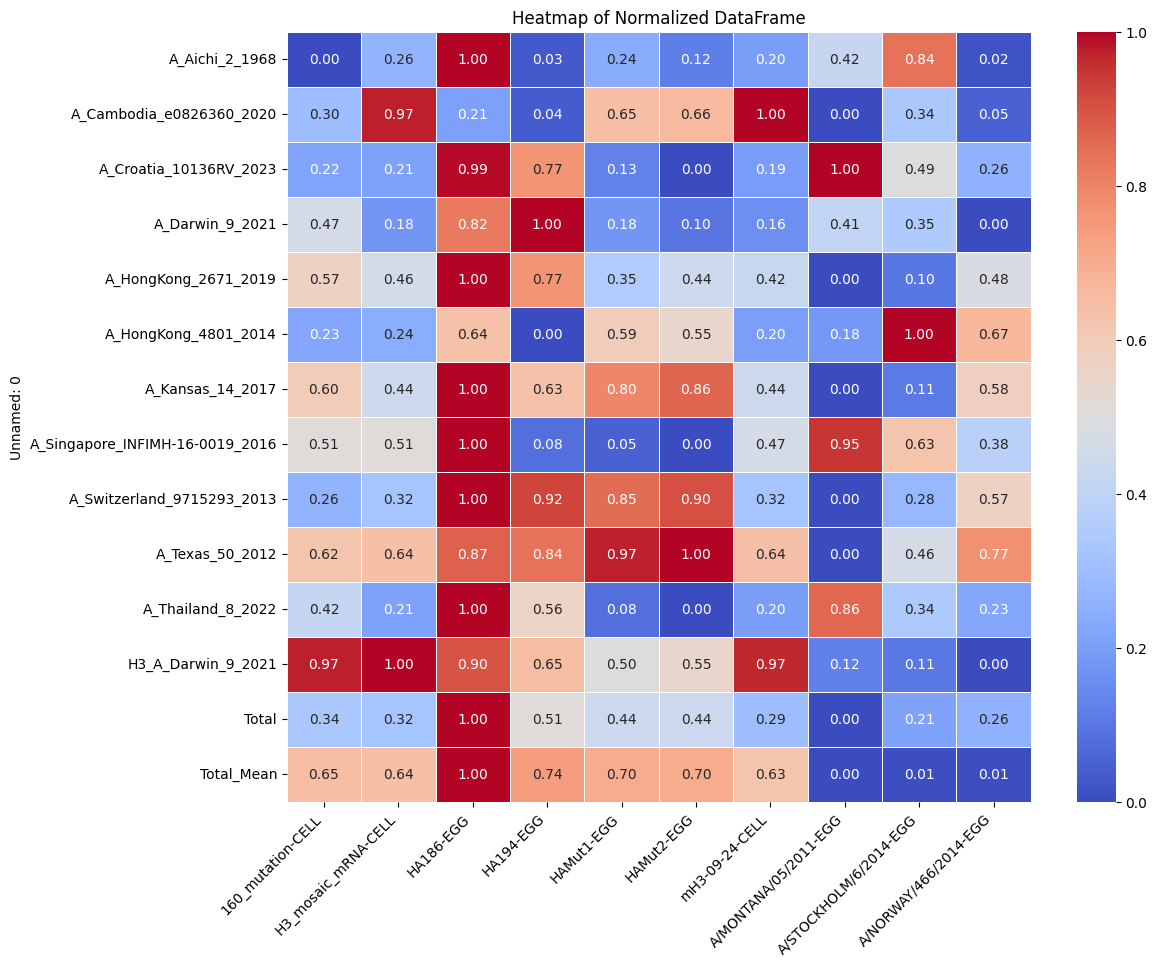

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 按行归一化
# 每个元素减去该行的最小值，再除以该行的最大值与最小值之差
plot_data_normalized = plot_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# 绘制热图
plt.figure(figsize=(12, 10))  # 设置热图的大小
sns.heatmap(plot_data_normalized, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, 
            xticklabels=plot_data.columns, yticklabels=plot_data.index)  # 绘制热图

# 设置列名倾斜 45 度
plt.xticks(rotation=45, ha='right')  # 旋转列名并设置水平对齐方式

plt.title("Heatmap of Normalized DataFrame")  # 添加标题
plt.savefig('./plt.png')